/workspaces/DECLINE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Predicted percentages (first 20 patients):
 Patient  Diagnosis(1-Anxiety, 0-No Anxiety)  Logistic Regression (%)  Random Forest (%)  XGBoost (%)
       1                                   1                    79.31              78.96        73.27
       2                                   0                     0.30               1.16         0.62
       3                                   0                     0.30               4.07         0.57
       4                                   0                     5.63              13.09         9.71
       5                                   0                     0.00               0.18         0.00
       6                                   0                    58.51              65.57        63.97
       7                                   0                    21.99              28.99        28.32
       8                                   0                    17.32              18.73        15.44
       9                              

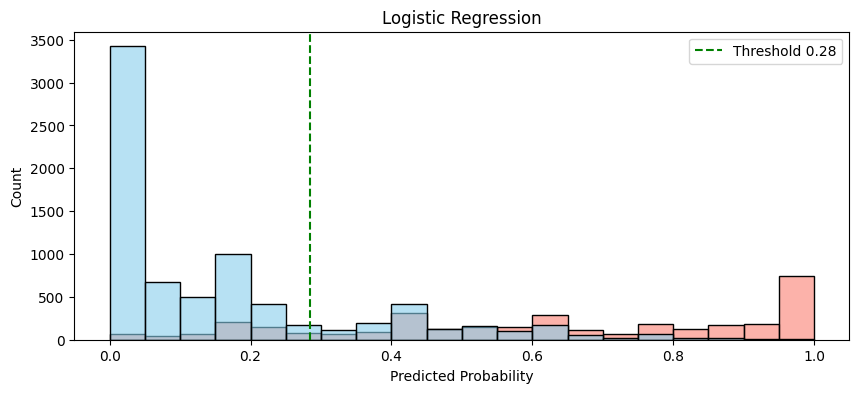

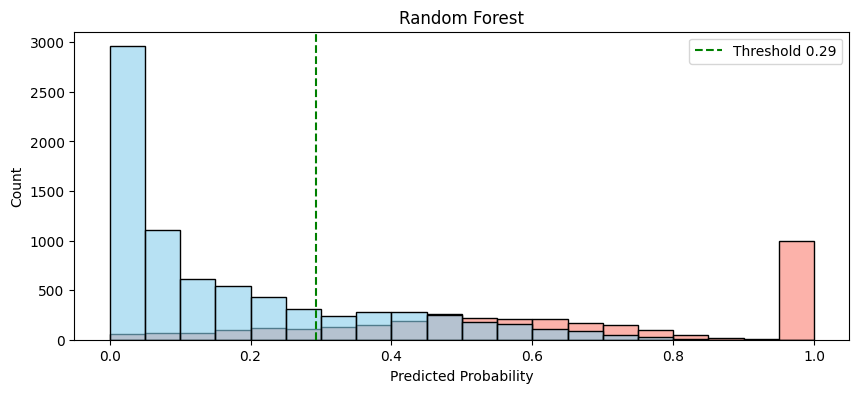

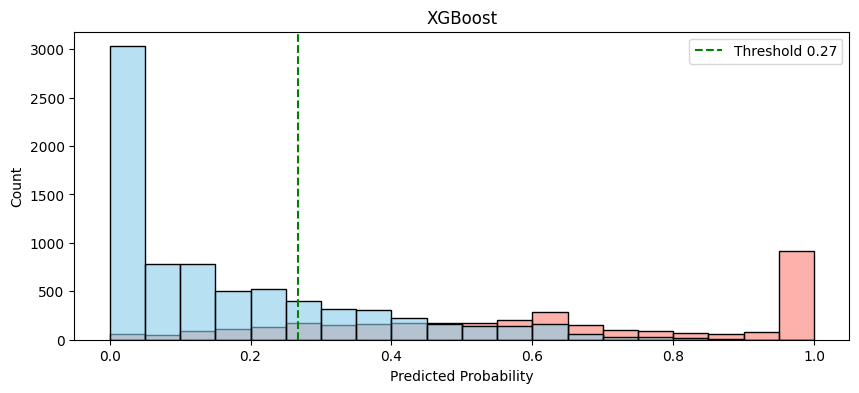


Top 15 features for Logistic Regression:
  Stress Level (1-10): 1.8771 (increases risk)
  Sleep Hours: -0.7585 (decreases risk)
  Therapy Sessions (per month): 0.5316 (increases risk)
  Caffeine Intake (mg/day): 0.4717 (increases risk)
  Occupation_Student: -0.1800 (decreases risk)
  Occupation_Nurse: 0.1441 (increases risk)
  Occupation_Doctor: 0.1422 (increases risk)
  Occupation_Other: 0.1068 (increases risk)
  Medication: 0.0897 (increases risk)
  Recent Major Life Event: 0.0809 (increases risk)
  Occupation_Lawyer: 0.0807 (increases risk)
  Occupation_Athlete: -0.0805 (decreases risk)
  Alcohol Consumption (drinks/week): 0.0739 (increases risk)
  Gender_Other: 0.0732 (increases risk)
  Age: -0.0731 (decreases risk)


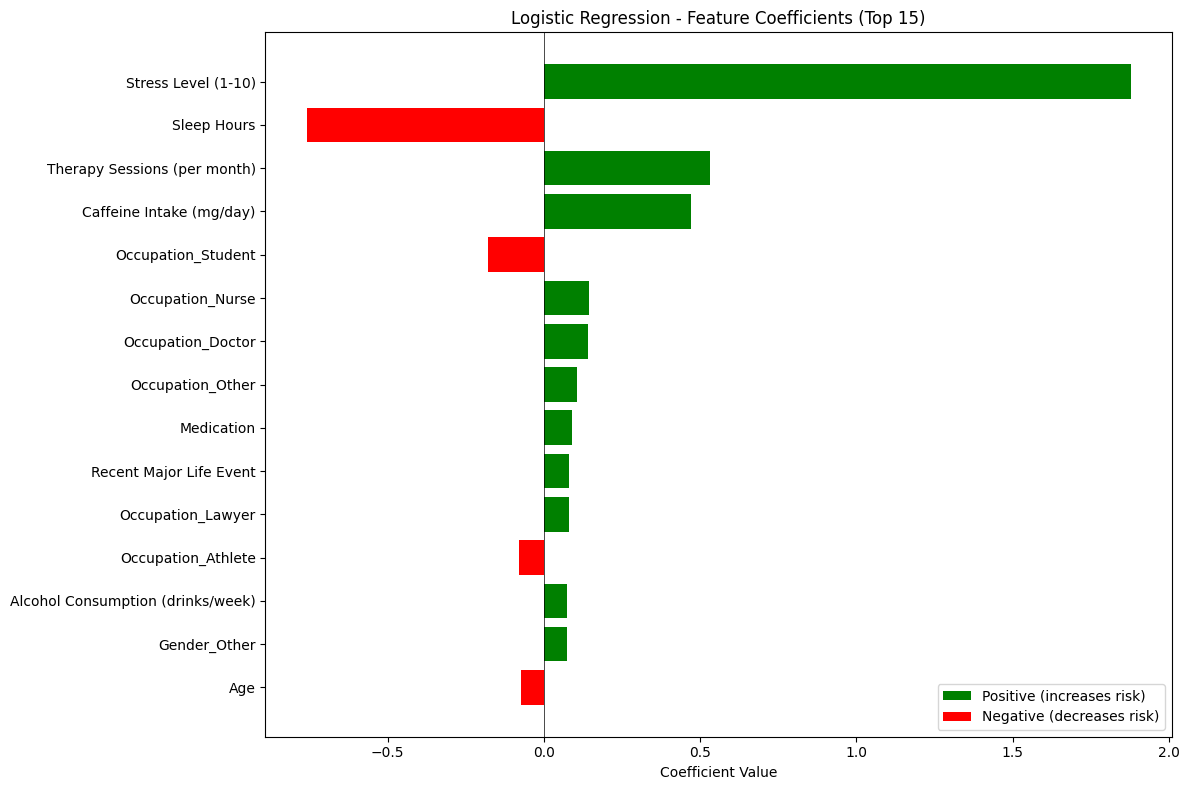


Top 15 features for Random Forest:
  Stress Level (1-10): 0.3114
  Sleep Hours: 0.1086
  Caffeine Intake (mg/day): 0.0850
  Physical Activity (hrs/week): 0.0589
  Therapy Sessions (per month): 0.0552
  Heart Rate (bpm): 0.0536
  Age: 0.0509
  Breathing Rate (breaths/min): 0.0438
  Alcohol Consumption (drinks/week): 0.0428
  Diet Quality (1-10): 0.0404
  Sweating Level (1-5): 0.0271
  Recent Major Life Event: 0.0100
  Medication: 0.0096
  Dizziness: 0.0095
  Gender_Other: 0.0089


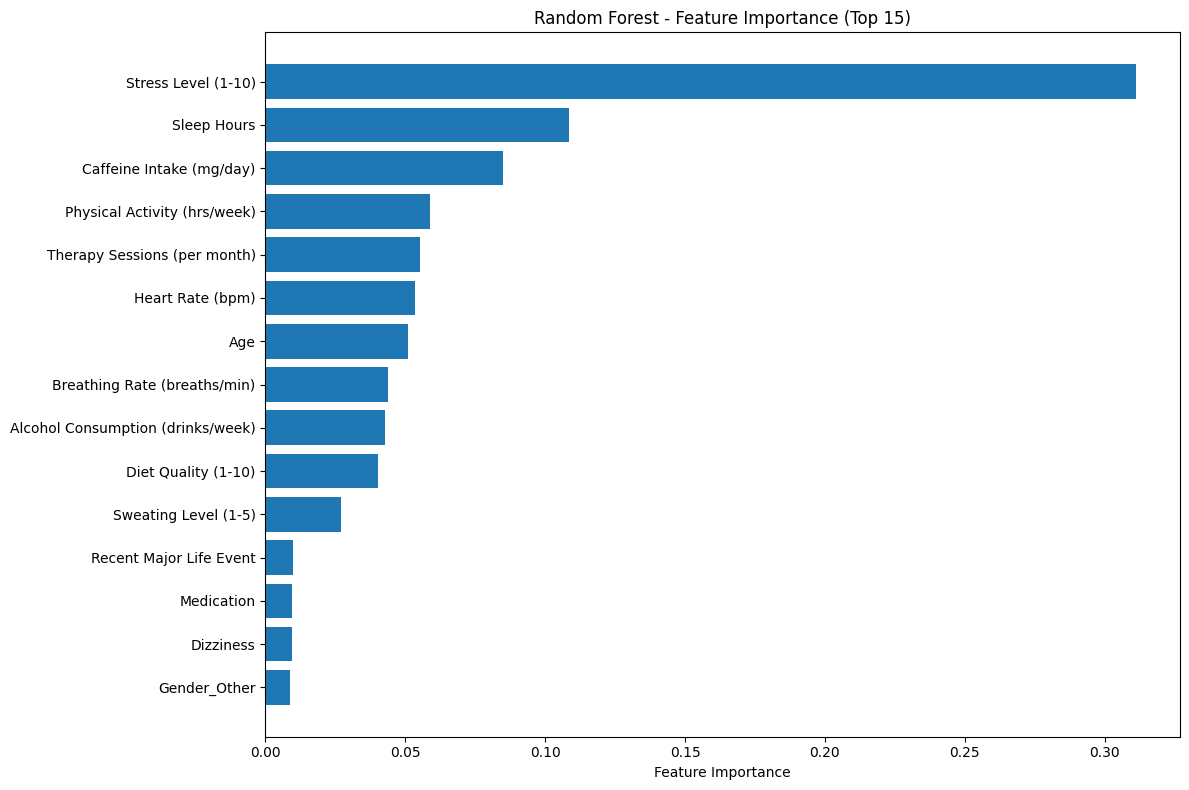


Top 15 features for XGBoost:
  Stress Level (1-10): 0.4402
  Sleep Hours: 0.0664
  Therapy Sessions (per month): 0.0482
  Caffeine Intake (mg/day): 0.0319
  Gender_Male: 0.0246
  Occupation_Athlete: 0.0218
  Occupation_Chef: 0.0201
  Occupation_Scientist: 0.0191
  Sweating Level (1-5): 0.0180
  Alcohol Consumption (drinks/week): 0.0176
  Occupation_Musician: 0.0176
  Diet Quality (1-10): 0.0166
  Occupation_Lawyer: 0.0164
  Age: 0.0162
  Physical Activity (hrs/week): 0.0162


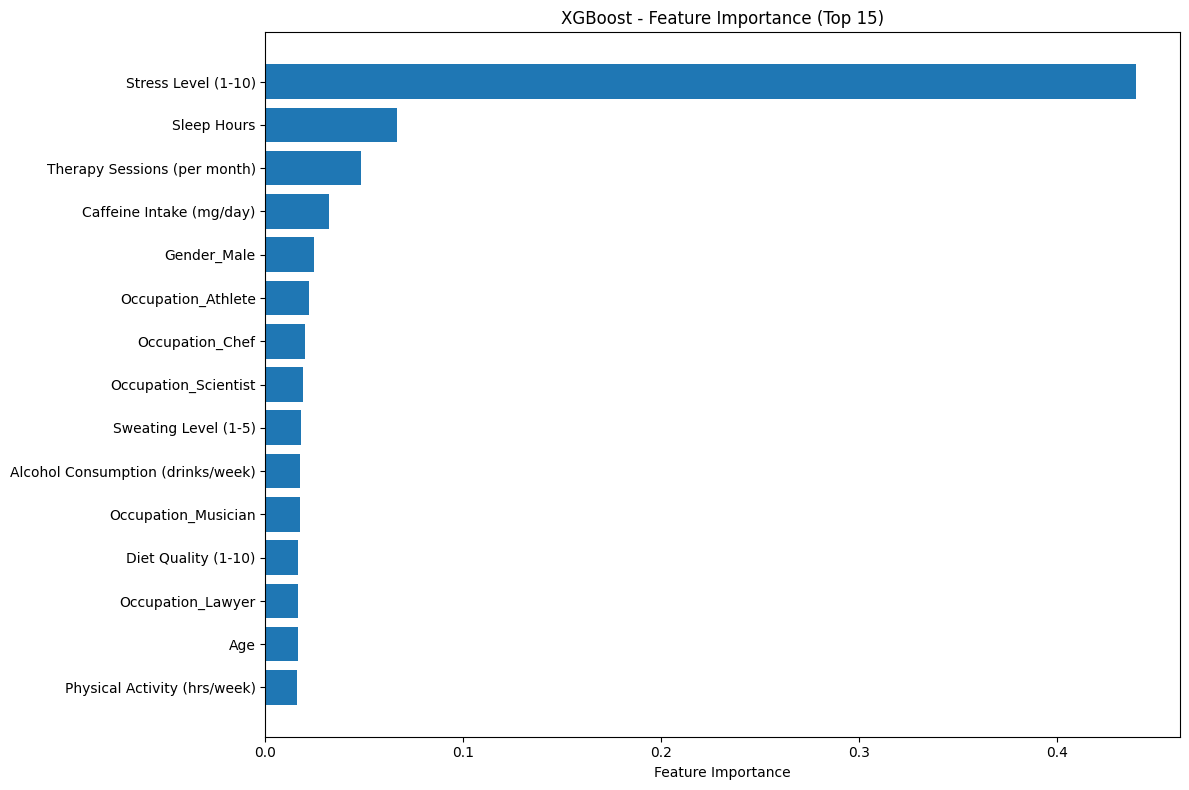

Logistic Regression METRICS (threshold=0.284)
Confusion Matrix:
  True Negatives: 6103
  False Positives: 1515
  False Negatives: 573
  True Positives: 2809

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8306 (83.06%)
  • SPECIFICITY (True Negative Rate): 0.8011 (80.11%)
  • F1-SCORE: 0.7290

Additional Metrics:
  Accuracy: 0.8102 (81.02%)
  Precision: 0.6496 (64.96%)
  ROC AUC: 0.9047
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9142    0.8011    0.8539      7618
           1     0.6496    0.8306    0.7290      3382

    accuracy                         0.8102     11000
   macro avg     0.7819    0.8159    0.7915     11000
weighted avg     0.8328    0.8102    0.8155     11000

Random Forest METRICS (threshold=0.293)
Confusion Matrix:
  True Negatives: 5923
  False Positives: 1695
  False Negatives: 510
  True Positives: 2872

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positi

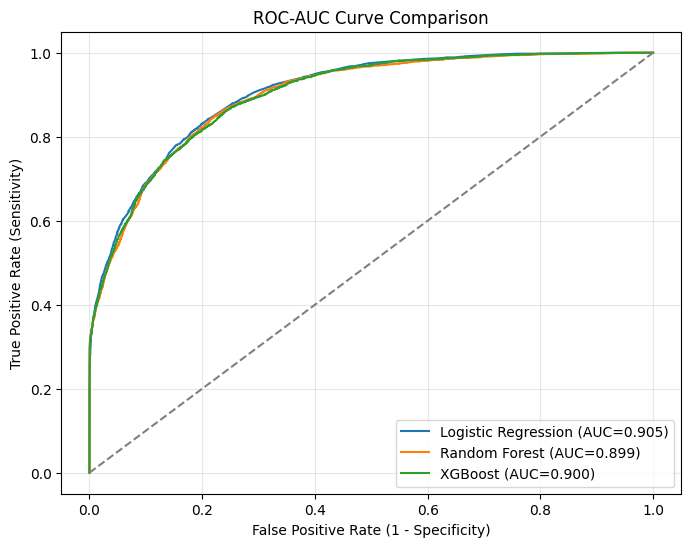

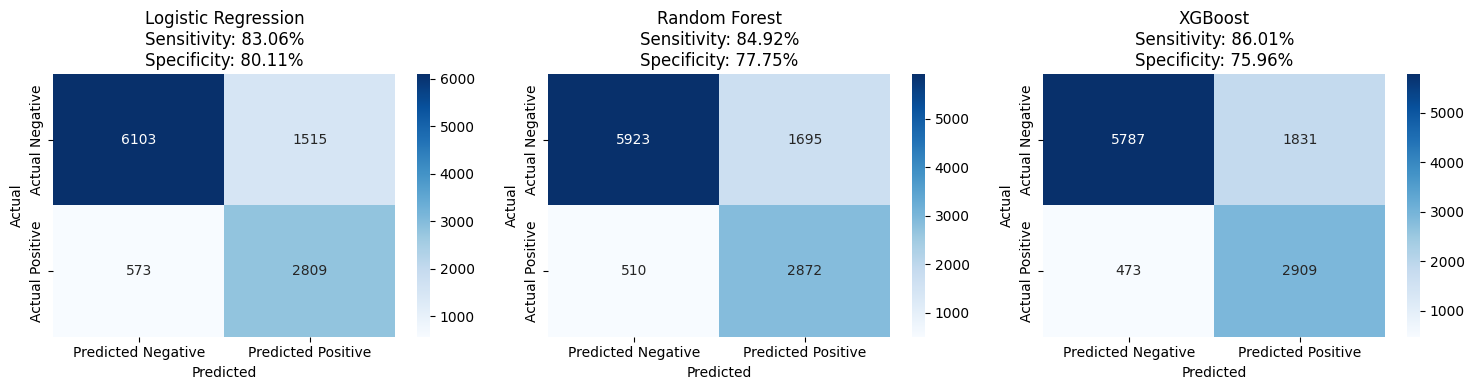

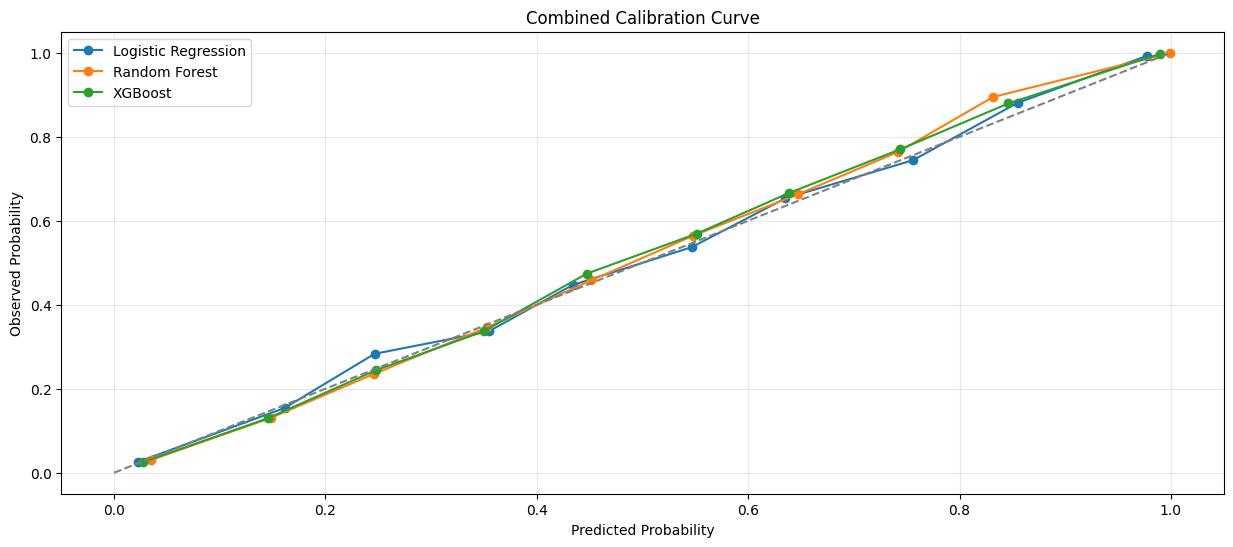


Generating SHAP Waterfall Plots for First 3 Patients...


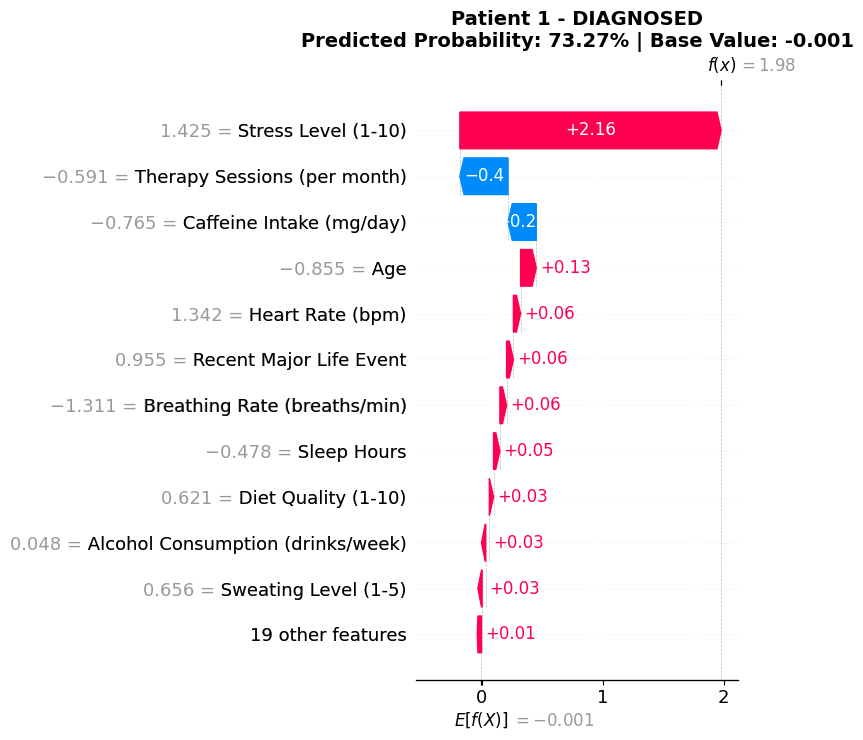

--------------------------------------------------------------------------------


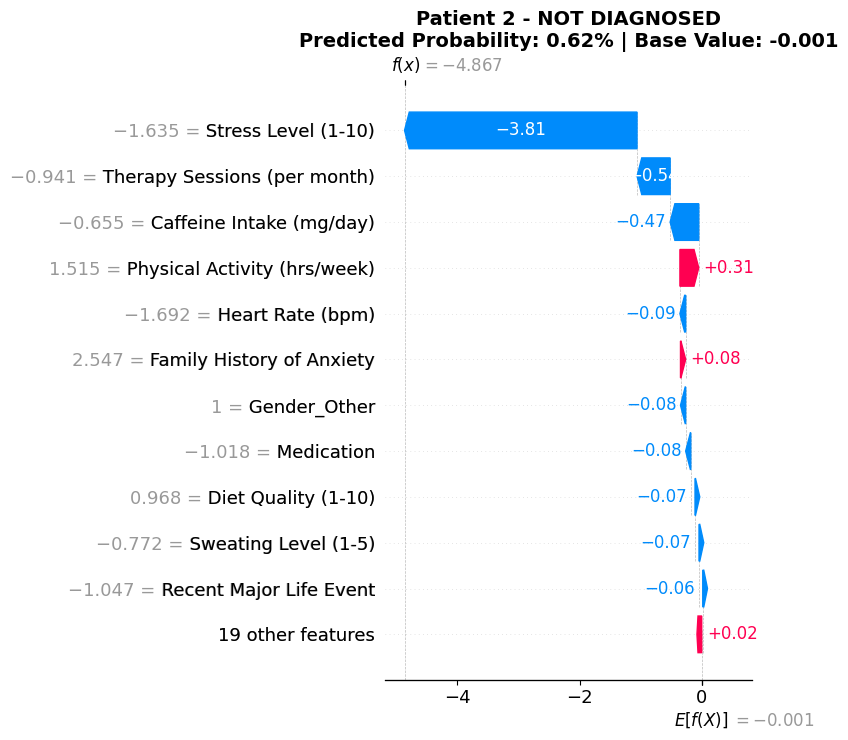

--------------------------------------------------------------------------------


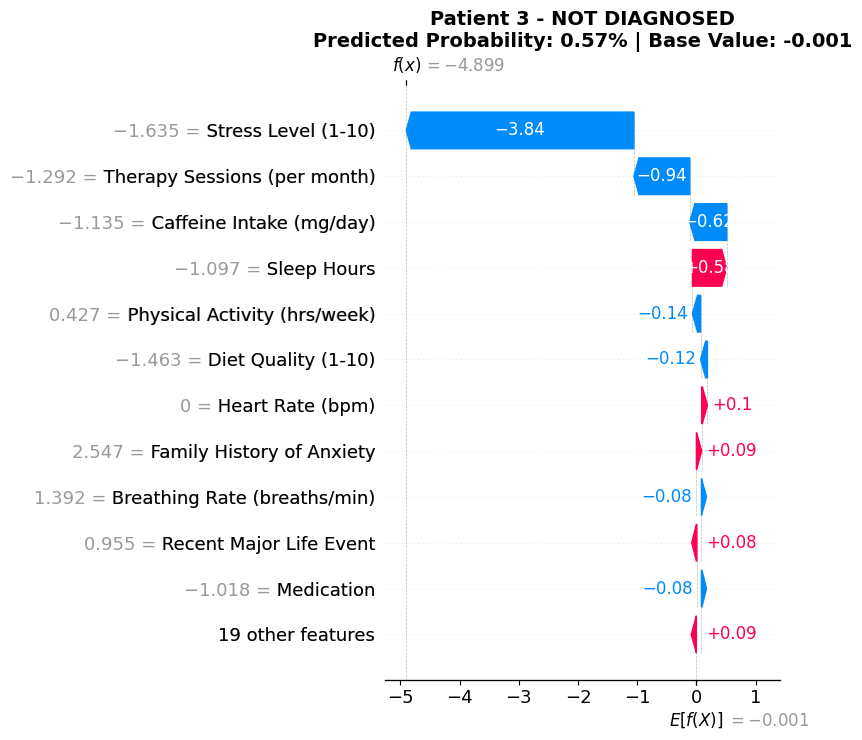

--------------------------------------------------------------------------------
RESULTS TABLE
FIRST 10 PATIENTS
Patient: 1     | Diagnosis: Diagnosed     | Prob: 73.27 % | Risk: High Risk   
  ↑ Increasing: Stress Level (1-10) (+2.160), Age (+0.130), Heart Rate (bpm) (+0.059), Recent Major Life Event (+0.057), Breathing Rate (breaths/min) (+0.055)
  ↓ Decreasing: Therapy Sessions (per month) (-0.399), Caffeine Intake (mg/day) (-0.233), Gender_Other (-0.022), Dizziness (-0.014), Smoking (-0.007)
--------------------------------------------------------------------------------------------------------------
Patient: 2     | Diagnosis: Not Diagnosed | Prob: 0.62  % | Risk: Low Risk    
  ↑ Increasing: Physical Activity (hrs/week) (+0.308), Family History of Anxiety (+0.085), Sleep Hours (+0.047), Occupation_Nurse (+0.039), Occupation_Student (+0.018)
  ↓ Decreasing: Stress Level (1-10) (-3.806), Therapy Sessions (per month) (-0.542), Caffeine Intake (mg/day) (-0.468), Heart Rate (bpm) (-0.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

# Load and prepare training data
train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Load and prepare test data
test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

# Identify feature types
numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Create preprocessing pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

# Create model pipelines
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

# Calibrate models
logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

# Train models
logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Get predicted probabilities
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Show first 20 predictions
print("\nPredicted percentages (first 20 patients):")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs.to_string(index=False))

# Find optimal thresholds
def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

# Plot probability distributions
def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x="Probability", hue="Diagnosis", bins=20, palette=["skyblue", "salmon"], alpha=0.6)
    plt.axvline(threshold, color="green", linestyle="--", label=f"Threshold {threshold:.2f}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.title(name)
    plt.legend()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

# feature importance function
def plot_feature_importance(pipeline_model, name):
    
    classifier = pipeline_model.named_steps["classifier"]

    preprocessor_temp = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    preprocessor_temp.fit(X_train)

    numeric_feature_names = numeric_features
    cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    feature_names = list(numeric_feature_names) + list(cat_feature_names)

    plt.figure(figsize=(12, 8))

    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        plt.barh(range(len(indices)), importances[indices])
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel("Feature Importance")
        plt.title(f"{name} - Feature Importance (Top 15)")
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            print(f"  {feature_names[idx]}: {importances[idx]:.4f}")

    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        abs_coef = np.abs(coefficients)
        indices = np.argsort(abs_coef)[-15:]
        colors = ['red' if c < 0 else 'green' for c in coefficients[indices]]
        plt.barh(range(len(indices)), coefficients[indices], color=colors)
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel("Coefficient Value")
        plt.title(f"{name} - Feature Coefficients (Top 15)")
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='green', label='Positive (increases risk)'),
                           Patch(facecolor='red', label='Negative (decreases risk)')]
        plt.legend(handles=legend_elements, loc='lower right')
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            direction = "increases risk" if coefficients[idx] > 0 else "decreases risk"
            print(f"  {feature_names[idx]}: {coefficients[idx]:.4f} ({direction})")

    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# Plot feature importance for all models
plot_feature_importance(logreg_pipeline, "Logistic Regression")
plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

# evaluation model
def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

   
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

# Evaluate models
logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

# Model comparison table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
}).round(2)

print("\nMODEL COMPARISON SUMMARY\n", comparison_df.to_string(index=False))

# ROC curve
plt.figure(figsize=(8,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
plt.plot([0,1], [0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]
for idx, (cm, ax, label) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, 
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{['Logistic Regression', 'Random Forest', 'XGBoost'][idx]}\n{label}")
plt.tight_layout()
plt.show()

# Calibration curve
plt.figure(figsize=(15,6))
for prob, label in zip([logreg_prob, rf_prob, xgb_prob], ["Logistic Regression", "Random Forest", "XGBoost"]):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=label)
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Probability")
plt.title("Combined Calibration Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Get feature names after preprocessing
preprocessor_temp = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])
preprocessor_temp.fit(X_train)

numeric_feature_names = numeric_features
cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = list(numeric_feature_names) + list(cat_feature_names)

# Transform the data
X_train_transformed = preprocessor_temp.transform(X_train)
X_test_transformed = preprocessor_temp.transform(X_test)

# Get the underlying XGBoost model (not the calibrated one)
xgb_model_uncalibrated = xgb_pipeline.named_steps['classifier']

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model_uncalibrated)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_transformed)

# Create waterfall plots for only 3 patients (first 3)
print("\nGenerating SHAP Waterfall Plots for First 3 Patients...")
print("="*60)

for i in range(min(3, len(X_test))):
    plt.figure(figsize=(12, 7))
    
    # Get prediction and true value
    pred_prob = xgb_prob[i]
    true_diag = y_test.iloc[i]
    
    # Create waterfall plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i], 
            base_values=explainer.expected_value,
            data=X_test_transformed[i],
            feature_names=feature_names
        ),
        show=False,
        max_display=12  # Show top 12 features for readability
    )
    
    # Add title with patient information
    plt.title(f"Patient {i+1} - {'DIAGNOSED' if true_diag == 1 else 'NOT DIAGNOSED'}\n"
              f"Predicted Probability: {pred_prob:.2%} | Base Value: {explainer.expected_value:.3f}", 
              fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    print("-" * 80)



print("RESULTS TABLE")

# Function to get top features for a patient based on SHAP values
def get_top_shap_features(shap_values_row, feature_names, n_top=5, positive=True):
    """
    Get top n features with highest positive or negative SHAP values
    """
    if positive:
        # Get indices of top positive SHAP values
        indices = np.argsort(shap_values_row)[-n_top:][::-1]
    else:
        # Get indices of top negative SHAP values (most negative)
        indices = np.argsort(shap_values_row)[:n_top]
    
    features = []
    for idx in indices:
        if positive and shap_values_row[idx] > 0:
            features.append(f"{feature_names[idx]} (+{shap_values_row[idx]:.3f})")
        elif not positive and shap_values_row[idx] < 0:
            features.append(f"{feature_names[idx]} ({shap_values_row[idx]:.3f})")
    
    # Pad with empty strings if less than n_top
    while len(features) < n_top:
        features.append("")
    
    return features

# Create risk categories based on predicted probability
def categorize_risk(prob, low_thresh=0.3, high_thresh=0.7):
    if prob < low_thresh:
        return "Low Risk"
    elif prob < high_thresh:
        return "Moderate Risk"
    else:
        return "High Risk"

xgb_risk_category = [categorize_risk(p) for p in xgb_prob]

# Get top features for each patient
top_increase_features = []
top_decrease_features = []

for i in range(len(xgb_prob)):
    increase_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=True)
    decrease_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=False)
    
    top_increase_features.append(increase_features)
    top_decrease_features.append(decrease_features)

# Create enhanced results table
results_table = pd.DataFrame({
    "Patient": range(1, len(xgb_prob) + 1),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": ["Diagnosed" if val == 1 else "Not Diagnosed" for val in y_test.values],
    "Predicted Prob (%)": np.round(xgb_prob * 100, 2),
    "Risk Category": xgb_risk_category,
    "Top 5 Increasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_increase_features],
    "Top 5 Decreasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_decrease_features]
})

# Set pandas display options for left alignment
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

# Display FIRST 10 patients
print("FIRST 10 PATIENTS")
for i in range(min(10, len(results_table))):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Display LAST 10 patients
print("LAST 10 PATIENTS")
start_idx = max(0, len(results_table) - 10)
for i in range(start_idx, len(results_table)):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

# Save full results table to CSV
results_table.to_csv("predictions_with_explanation.csv", index=False)
print("\nFull results table saved to 'predictions_with_explanations.csv'")

# Create summary statistics for risk categories
print("RISK CATEGORY DISTRIBUTION")
risk_summary = results_table.groupby('Risk Category').agg({
    'Patient': 'count',
}).rename(columns={'Patient': 'Count'})
risk_summary['Percentage'] = (risk_summary['Count'] / len(results_table) * 100).round(2)
print(risk_summary.to_string())

# Save model
joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")